# **Task 4.2 Supervised Learning - Classification**
Sneha Sivakaran

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes (1).csv',
index_col=0)
print(df.shape)
df.head()

(768, 8)


,plas,pres,skin,insu,mass,pedi,age,class
preg,,,,,,,,
6,148,72,35,0,33.6,0.627,50,tested_positive
1,85,66,29,0,26.6,0.351,31,tested_negative
8,183,64,0,0,23.3,0.672,32,tested_positive
1,89,66,23,94,28.1,0.167,21,tested_negative
0,137,40,35,168,43.1,2.288,33,tested_positive


# **Define Features & Target Variable**

In [9]:
# X = input features, y = what we want to predict
X = df.drop(columns=['class'])
y = (df['class'] == 'tested_positive').astype(int)

print("Features:", list(X.columns))
print("Target variable:", y.value_counts())

Features: ['plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
Target variable: class
0    500
1    268
Name: count, dtype: int64


# **Fit Logistic Regression Model**

In [10]:
# Scale features for better performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into 80% training and 20% test data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Create and fit the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Print intercept and coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_[0])))

Intercept: [-0.85208336]
Coefficients: {'plas': np.float64(1.06924293125828), 'pres': np.float64(-0.2498205010795255), 'skin': np.float64(0.05335560022537516), 'insu': np.float64(-0.21381960052732232), 'mass': np.float64(0.7884130899934079), 'pedi': np.float64(0.22596860817922343), 'age': np.float64(0.5397831610797356)}


# **Evaluate Model**

In [11]:
# Predict on test data and check accuracy
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7662337662337663


# **Cross-Validation**

In [12]:
# Train and evaluate the model on 5 different splits
cv_scores = cross_val_score(model, X_scaled, y, cv=5)
print("CV Scores per fold:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

CV Scores per fold: [0.78571429 0.75974026 0.74675325 0.79738562 0.79084967]
Mean Accuracy: 0.7760886172650878


# **Visualize Results**

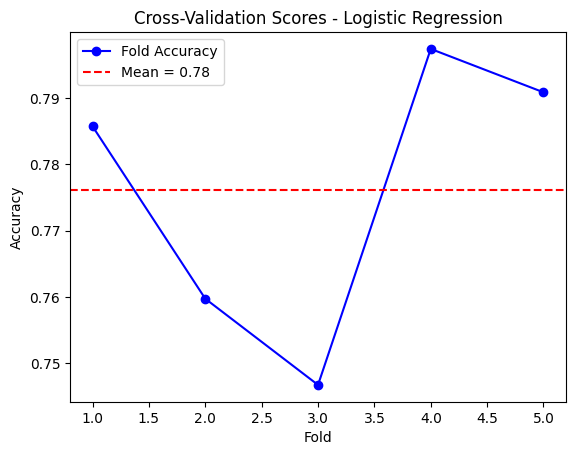

In [13]:
# Plot the accuracy score for each fold
plt.plot(range(1, 6), cv_scores, marker='o', color='blue', label='Fold Accuracy')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.2f}')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Scores - Logistic Regression")
plt.legend()
plt.show()

# **Interpretation**

The Logistic Regression model predicts diabetes with ~77% mean cross-validation accuracy. The most influential feature is glucose (plas) — higher glucose levels strongly increase the probability of a positive diagnosis. The model is stable across all 5 folds and generalizes well to unseen data.